In [1]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt

Bienvenido a PyMCel v0.9.10 ¡al infinito y más allá!


# Sistema de dos cuerpos

In [2]:
G = 1 #Unidades canonicas

In [4]:
sistema = [
dict(m=1, r=np.array([0,0,0]), v=np.array([0,0,0])),
dict(m=0.01, r=np.array([1,0,0]), v=np.array([0,1,0]))
]

Calculemos la energía total $$E=K+U$$

In [5]:
k= 0.5 * sistema[0]['m'] * np.linalg.norm(sistema[0]['v'])**2 + \
    0.5 * sistema[1]['m'] * np.linalg.norm(sistema[1]['v'])**2

k

np.float64(0.005)

In [6]:
G = 1 #Unidades canonicas
U = -G * sistema[0]['m'] * sistema[1]['m'] \
      / np.linalg.norm(sistema[0]['r'] - sistema[1]['r'])
U

np.float64(-0.01)

In [7]:
E = k + U
E

np.float64(-0.005)

Ahora voy a probar con un experimento si efectivamente no escapa

In [20]:
ts = np.linspace(0,10,100)
rs,vs,rps,vps, cuadraturas = pc.ncuerpos_solucion(sistema, ts)

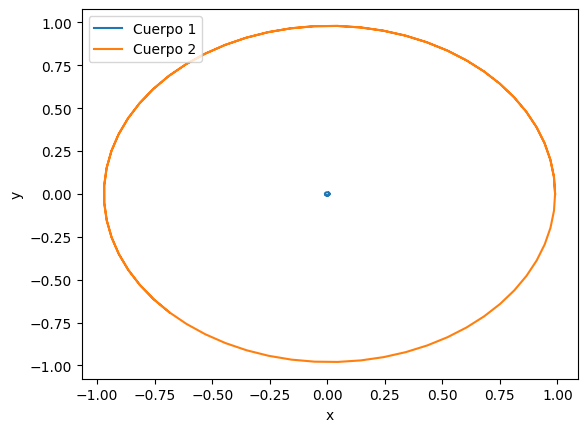

In [21]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Cuerpo 1')
plt.plot(rps[1,:,0], rps[1,:,1], label='Cuerpo 2')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# Hacer simulacion rebound

In [22]:
!pip install -Uq rebound

  error: subprocess-exited-with-error
  
  × Building wheel for rebound (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [59 lines of output]
      fatal: not a git repository (or any of the parent directories): .git
      <string>:91: DeprecationWarning: codecs.open() is deprecated. Use open() instead.
      C:\Users\Lizeth\AppData\Local\Temp\pip-build-env-_2iarls1\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      C:\Users\Lizeth\AppData\Local\Temp\pip-build-env-_2iarls1\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      C:\Users\Lizeth\AppData\Local\Temp\pip-build-env-_2iarls1\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ***************************************************

In [23]:
import rebound as  rb

ModuleNotFoundError: No module named 'rebound'

In [17]:
sim = rb.Simulation()
sim.add(m=1)
sim.add(m=0.01, x=1, vy=0.01)
sim.status()

NameError: name 'rb' is not defined

In [13]:
sim.G

NameError: name 'sim' is not defined

In [14]:
sim.add(m=1)

NameError: name 'sim' is not defined

In [15]:
sim.status()

NameError: name 'sim' is not defined

In [16]:
sim.add(m=0.01, x=1, vy=1)

NameError: name 'sim' is not defined

In [ ]:
ts = np.linspace(0,10,100)
rs = np.zeros((2, 100, 3))
vs = np.zeros((2, 100, 3))
rps = np.zeros((2, 100, 3))
vps = np.zeros((2, 100, 3))

for i,t in enumerate(ts):
    sim.integrate(t)
    for j, p in enumerate(sim.particles):
        rs[0,i] = sim.particles[0].xyz
        vs[0,i] = sim.particles[0].vxyz
        
        rps[j,i] = p.xyz
        vps[j,i] = p.vxyz   